# Exploratory Analysis

**Purpose:** Explore descriptive stats and features

## Import Libraries

In [1]:
# Import necessary libraries for data analysis and visualization
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Read and Clean Data

In [2]:
# Read data from CSV files
df_rock = pd.read_csv('../data/rock.csv')
df_alternative = pd.read_csv('../data/alternative.csv')
df_pop = pd.read_csv('../data/pop.csv')
df_rap_rb = pd.read_csv('../data/rap-r&b.csv')
df_liked_songs = pd.read_csv('../data/liked_songs.csv')

# Add playlist column to each dataset
df_rock['Playlist'] = 'Rock'
df_alternative['Playlist'] = 'Alternative'
df_pop['Playlist'] = 'Pop'
df_rap_rb['Playlist'] = 'Rap-R&B'
df_liked_songs['Playlist'] = 'Liked Songs'

# Create one combined dataframe for all playlists
df_library = pd.concat([df_rock, df_alternative, df_pop, df_rap_rb, df_liked_songs]
                       ).drop_duplicates(['Song', 'Artist'], keep='first').sort_values(by=['Song']
                       ).reset_index(drop=True).drop(columns=['#'])

# Add album year from 'Album Date' column and create a new column 'Album Year' as year
df_library['Album Year'] = df_library['Album Date'].str[:4].astype(int)

# Save the cleaned and combined dataframe to a new CSV file
df_library.to_csv('../data/music_library.csv', index=False)

# View df_library
df_library

,Song,Artist,BPM,Camelot,Energy,Added At,Duration,Popularity,Genres,Album,...,Valence,Speech,Live,Loud (Db),Key,Time Signature,Spotify Track Id,ISRC,Playlist,Album Year
0,#1,Nelly,180,9B,59,2026-03-10,03:18,57,NaN,Nellyville,...,46,30,50,-6,G Major,4,7rSj5gEdN5KgHwbnEVAZ4b,USUR10200366,Rap-R&B,2002
1,#1 Crush - Nellee Hooper Mix,"Garbage,Nellee Hooper",94,7B,63,2026-03-30,04:50,51,NaN,Garbage (20th Anniversary Deluxe Edition/Remas...,...,49,0,30,-7,F Major,4,08L1WAtYQnsFBoZ3MEBkYV,GBPVV1501060,Liked Songs,1995
2,#88,Lo-Fang,135,9B,34,2026-03-16,05:48,0,NaN,#88,...,40,0,0,-10,G Major,4,1jjwFHRnfgBTJ049RJz8CQ,GBAFL2000240,Alternative,2013
3,&Run,Sir Sly,92,7B,66,2026-03-02,03:46,60,NaN,"Don't You Worry, Honey",...,48,0,10,-8,F Major,4,0w4m3Xp4svlIoyL94Zjlyd,USUM71704895,Liked Songs,2017
4,(I Can't Get No) Satisfaction - Mono,The Rolling Stones,136,10B,86,2026-03-16,03:42,74,"classic rock, rock",Out Of Our Heads,...,93,0,10,-8,D Major,4,2PzU4IB8Dr6mxV3lHuaG34,USA176510160,Rock,1965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1779,wet dreams,Artemas,126,9B,72,2026-03-02,01:39,54,NaN,wet dreams,...,4,0,20,-6,G Major,4,05EXzecgWqEuk5ph43jRq9,QZJ842401770,Liked Songs,2024
1780,yeti,"Paris Paloma,Old Sea Brigade",139,10A,39,2026-03-30,04:12,49,"indie folk, folk pop",Cacophony,...,25,0,10,-11,B Minor,4,09cCZPsr05CpO15RgnHCr7,CAN112300618,Liked Songs,2024
1781,you should see me in a crown,Billie Eilish,150,12B,53,2026-03-02,03:00,77,NaN,"WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?",...,32,10,10,-10,E Major,4,3XF5xLJHOQQRbWya6hBp7d,USUM71810049,Liked Songs,2019
1782,you've been a bad girl,Artemas,137,9A,87,2026-03-30,02:23,60,NaN,yustyna,...,37,0,10,-2,E Minor,4,6Gron8VFcNPwj7ZamJe7Pt,QZJ842401766,Liked Songs,2024


## Explore Data

### Songs by Playlist

In [3]:
songs_by_playlist = df_library.groupby('Playlist').size().reset_index(name='Count')
print(songs_by_playlist)

      Playlist  Count
0  Alternative    250
1  Liked Songs    784
2          Pop    250
3      Rap-R&B    250
4         Rock    250


### Songs by Artists

In [4]:
# Count the number of songs by each artist in the library
df_artists = df_library['Artist'].value_counts().reset_index()
df_artists.columns = ['Artist', 'Count']

# Group by playlist and artist to count the number of songs by each artist in each playlist
df_artists_by_playlist = df_library.groupby(['Playlist', 'Artist']).size().reset_index(name='Count')

# Count the number of unique artists in each playlist
unique_artists_by_playlist = df_library.groupby('Playlist')['Artist'].nunique().reset_index(name='Unique Artists')

# Print number of artists
print(f"Number of unique artists in the library: {len(df_artists)}")

# Print number of unique artists by playlist
print("\nNumber of unique artists by playlist:")
for index, row in unique_artists_by_playlist.iterrows():
    print(f"  {row['Playlist']}: {row['Unique Artists']}") 

# Return df_artists
df_artists

Number of unique artists in the library: 914

Number of unique artists by playlist:
  Alternative: 152
  Liked Songs: 457
  Pop: 141
  Rap-R&B: 182
  Rock: 144


,Artist,Count
0,The Neighbourhood,19
1,Matt Maeson,19
2,Florence + The Machine,19
3,MEG MYERS,16
4,Maroon 5,16
...,...,...
909,Stevie Howie,1
910,YUNGBLUD,1
911,dye,1
912,Christian French,1


In [5]:
def plot_artist_distribution(df, playlist=None, bin_max=9, ax=None):
    """
    Plot distribution of song counts per artist.
    
    Args:
        df: DataFrame with artist counts (must have 'Count' column)
        playlist: If provided, filter to this playlist (requires 'Playlist' column)
        bin_max: Counts above this are binned as '{bin_max+1}+'
        ax: Matplotlib axes to plot on (creates new figure if None)
    """
    # Filter if playlist specified
    if playlist:
        df = df[df['Playlist'] == playlist]
        title = playlist
    else:
        title = 'Distribution of Song Count by Artist'
    
    # Bin the counts
    def bin_count(x):
        return str(x) if x <= bin_max else f'{bin_max + 1}+'
    
    bin_order = [str(i) for i in range(1, bin_max + 1)] + [f'{bin_max + 1}+']
    bins = df['Count'].apply(bin_count)
    freq = bins.value_counts().reindex(bin_order, fill_value=0)
    
    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
        standalone = True
    else:
        standalone = False
    
    ax.bar(freq.index, freq.values, color='steelblue', edgecolor='white')
    ax.set_xlabel('Number of Songs')
    ax.set_ylabel('Number of Artists')
    ax.set_title(title)
    
    if standalone:
        plt.tight_layout()
        plt.show()

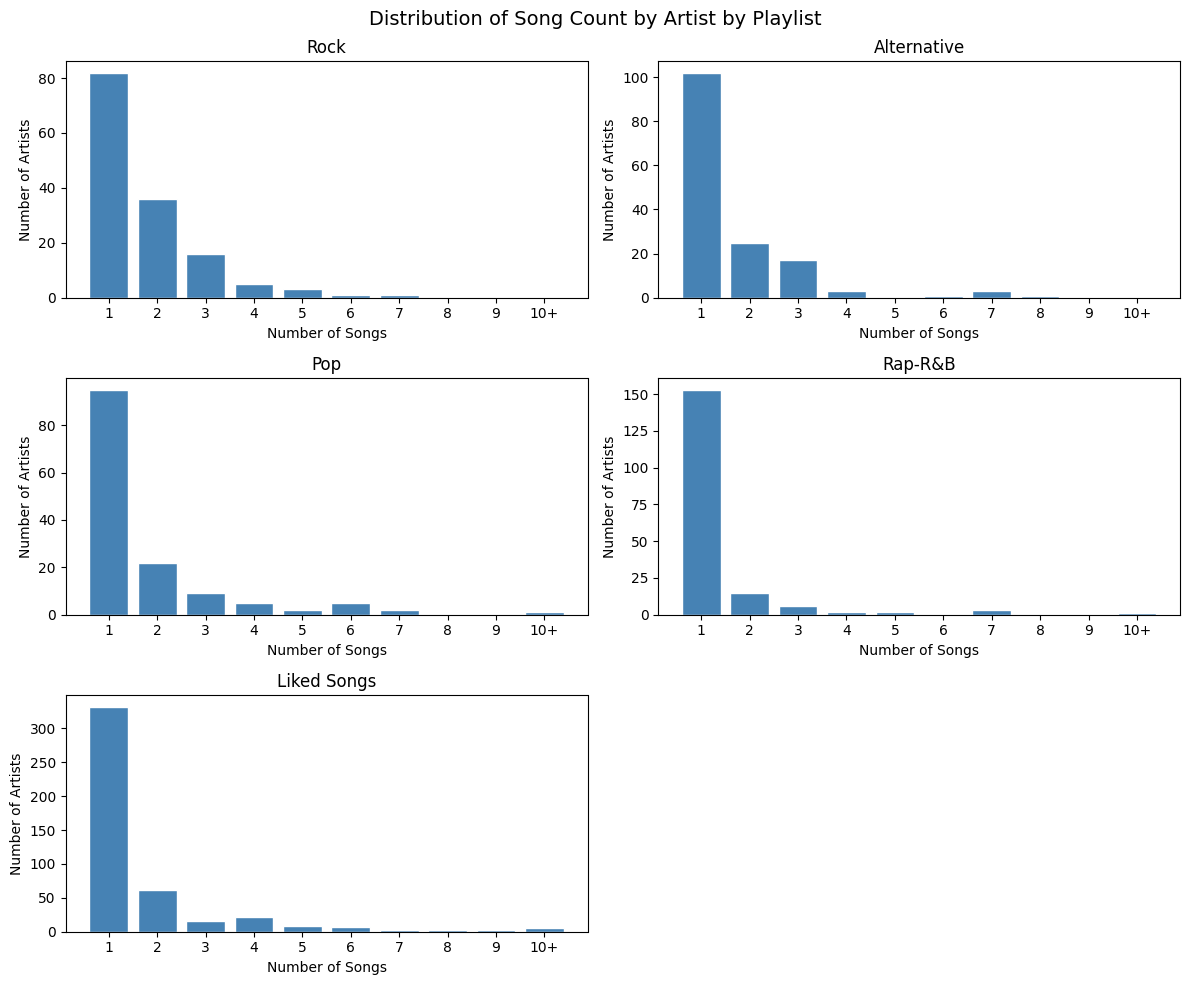

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
playlists = ['Rock', 'Alternative', 'Pop', 'Rap-R&B', 'Liked Songs']

for ax, playlist in zip(axes.flatten(), playlists):
    plot_artist_distribution(df_artists_by_playlist, playlist=playlist, ax=ax)

fig.suptitle('Distribution of Song Count by Artist by Playlist', fontsize=14)
axes.flatten()[5].axis('off')
plt.tight_layout()
plt.show()

### Album Year

In [7]:
# Bin album release years into decades
def bin_decade(year):
    if pd.isna(year):
        return 'Unknown'
    year = int(year)
    if year < 1970:
        return '1960s'
    elif year < 1980:
        return '1970s'
    elif year < 1990:
        return '1980s'
    elif year < 2000:
        return '1990s'
    elif year < 2010:
        return '2000s'
    elif year < 2020:
        return '2010s'
    else:
        return '2020s'

decade_order = ['1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s', 'Unknown']

df_library['Decade'] = df_library['Album Year'].apply(bin_decade)
decade_counts = df_library['Decade'].value_counts().reindex(decade_order, fill_value=0)
decade_counts

Decade
1960s       10
1970s       41
1980s       79
1990s      120
2000s      504
2010s      669
2020s      361
Unknown      0
Name: count, dtype: int64

In [8]:
# Get decade counts by playlist
decade_counts_by_playlist = (
    df_library.groupby(['Playlist', 'Decade'])
    .size()
    .reindex(pd.MultiIndex.from_product([['Alternative', 'Pop', 'Rap-R&B', 'Rock', 'Liked Songs'], decade_order], names=['Playlist', 'Decade']), fill_value=0)
    .reset_index(name='Count')
)

# Pivot dataframe
decade_pivot = decade_counts_by_playlist.pivot(index='Playlist', columns='Decade', values='Count')
decade_pivot.loc['Total'] = decade_pivot.sum()
decade_pivot

Decade,1960s,1970s,1980s,1990s,2000s,2010s,2020s,Unknown
Playlist,,,,,,,,
Alternative,0,0,0,0,0,190,60,0
Liked Songs,5,4,15,33,206,285,236,0
Pop,1,4,19,43,121,44,18,0
Rap-R&B,0,0,5,25,110,84,26,0
Rock,4,33,40,19,67,66,21,0
Total,10,41,79,120,504,669,361,0


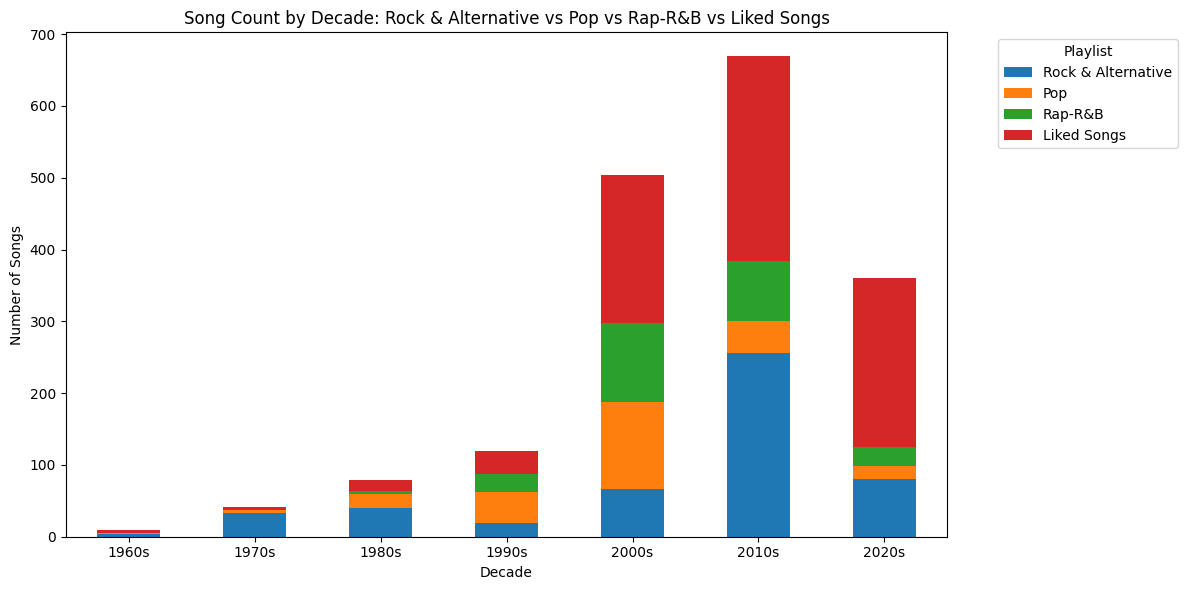

In [9]:
decade_order_plot = ['1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

plot_data = decade_pivot.loc[['Rock', 'Alternative', 'Pop', 'Rap-R&B', 'Liked Songs'], decade_order_plot].copy()
plot_data.loc['Rock & Alternative'] = plot_data.loc['Rock'] + plot_data.loc['Alternative']
plot_data = plot_data.loc[['Rock & Alternative', 'Pop', 'Rap-R&B', 'Liked Songs'], decade_order_plot]

plot_data.T.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel('Decade')
plt.ylabel('Number of Songs')
plt.title('Song Count by Decade: Rock & Alternative vs Pop vs Rap-R&B vs Liked Songs')
plt.legend(title='Playlist', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# Analyze songs from 1995-2005 (CD era)
df_cds = df_library[(df_library['Album Year'] >= 1995) & (df_library['Album Year'] < 2006)]
print(f"Number of songs from 1995-2005: {len(df_cds)}")
print('Average number of songs per year in 1995-2005:', round(len(df_cds) / 11, 1))
print('Range of songs per year:', df_cds['Album Year'].value_counts().min(), '-', df_cds['Album Year'].value_counts().max())

# Analyze songs from 2006-2014 (iTunes era)
df_itunes = df_library[(df_library['Album Year'] >= 2006) & (df_library['Album Year'] < 2015)]
print(f"\nNumber of songs from 2006-2014: {len(df_itunes)}")
print('Average number of songs per year in 2006-2014:', round(len(df_itunes) / 9, 1))
print('Range of songs per year:', df_itunes['Album Year'].value_counts().min(), '-', df_itunes['Album Year'].value_counts().max())

# Analyze songs from 2015-2025 (Spotify era)
df_spotify = df_library[(df_library['Album Year'] >= 2015) & (df_library['Album Year'] < 2026)]
print(f"\nNumber of songs from 2015-2025: {len(df_spotify)}")
print('Average number of songs per year in 2020s:', round(len(df_spotify) / 11, 1))
print('Range of songs per year:', df_spotify['Album Year'].value_counts().min(), '-', df_spotify['Album Year'].value_counts().max())


Number of songs from 1995-2005: 330
Average number of songs per year in 1995-2005: 30.0
Range of songs per year: 12 - 60

Number of songs from 2006-2014: 554
Average number of songs per year in 2006-2014: 61.6
Range of songs per year: 49 - 75

Number of songs from 2015-2025: 690
Average number of songs per year in 2020s: 62.7
Range of songs per year: 36 - 89


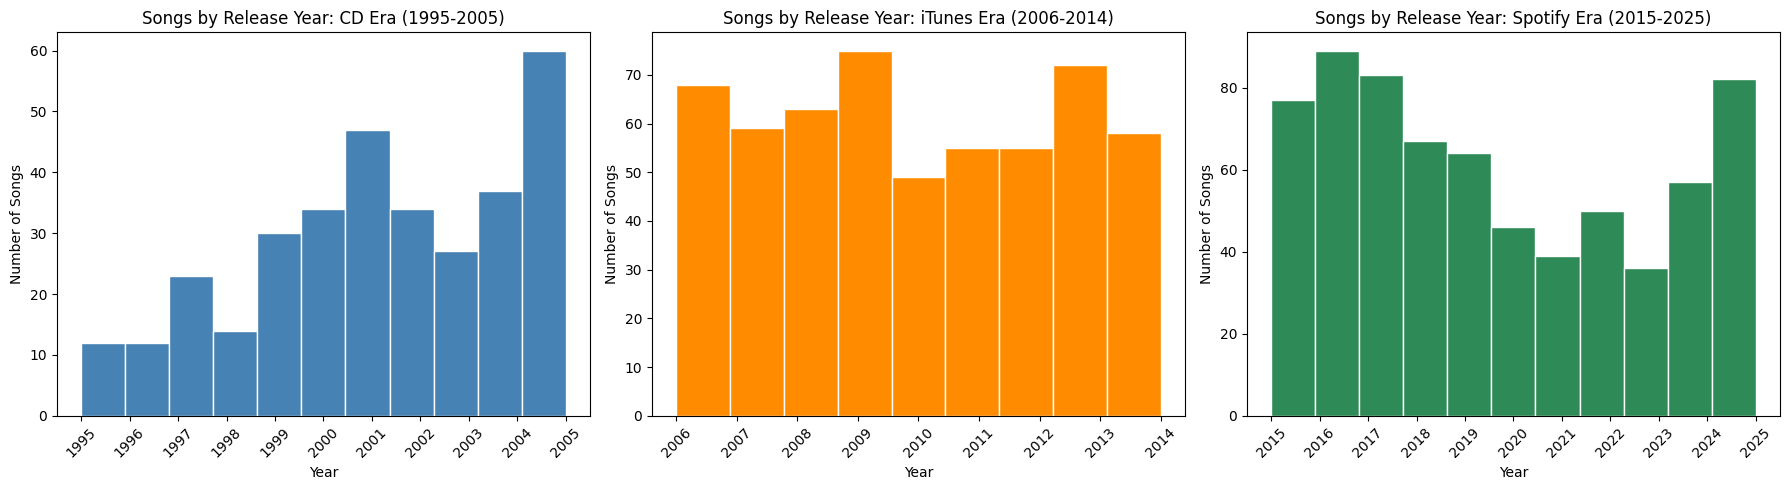

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

eras = [
    (df_cds, range(1995, 2006), 'Songs by Release Year: CD Era (1995-2005)', 'steelblue'),
    (df_itunes, range(2006, 2015), 'Songs by Release Year: iTunes Era (2006-2014)', 'darkorange'),
    (df_spotify, range(2015, 2026), 'Songs by Release Year: Spotify Era (2015-2025)', 'seagreen'),
]

for ax, (df, xticks, title, color) in zip(axes, eras):
    ax.hist(df['Album Year'], bins=len(xticks), color=color, edgecolor='white')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Songs')
    ax.set_title(title)
    ax.set_xticks(xticks)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Popularity

In [12]:
df_library['Popularity'].describe()

count    1784.000000
mean       56.679933
std        19.052754
min         0.000000
25%        45.000000
50%        59.000000
75%        71.000000
max        98.000000
Name: Popularity, dtype: float64

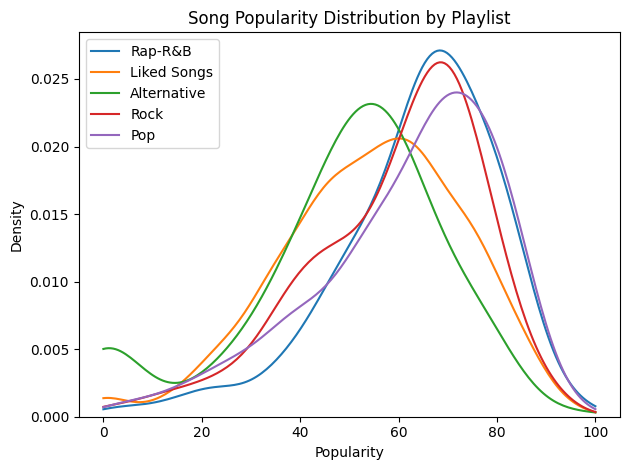

In [13]:
for playlist in df_library['Playlist'].unique():
    df_playlist = df_library[df_library['Playlist'] == playlist]
    sns.kdeplot(df_playlist['Popularity'], label=playlist, clip=(0, 100))

plt.xlabel('Popularity')
plt.ylabel('Density')
plt.title('Song Popularity Distribution by Playlist')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Selection

In [14]:
METADATA = ['Song', 'Artist', 'Album', 'Playlist']
X = ['BPM', 'Valence', 'Dance', 'Energy', 'Acoustic', 'Loud (Db)', 'Speech', 'Live', 'Time Signature', 'Album Year', 'Popularity']

df_metadata = df_library[METADATA]
df_X = df_library[X]

print(df_X.describe())

               BPM      Valence        Dance       Energy     Acoustic  \
count  1784.000000  1784.000000  1784.000000  1784.000000  1784.000000   
mean    122.266816    50.195067    62.090247    68.610426    15.700112   
std      28.512879    23.562379    15.317219    17.989687    21.793228   
min      47.000000     4.000000    12.000000     3.000000     0.000000   
25%     100.000000    32.000000    52.000000    57.000000     1.000000   
50%     120.000000    49.000000    62.000000    71.000000     6.000000   
75%     140.000000    68.000000    73.000000    83.000000    21.000000   
max     211.000000    98.000000    99.000000    99.000000    98.000000   

         Loud (Db)       Speech         Live  Time Signature   Album Year  \
count  1784.000000  1784.000000  1784.000000     1784.000000  1784.000000   
mean     -6.589126     3.744395    13.408072        3.971973  2010.040359   
std       2.811106     8.432618    14.032230        0.230339    11.777692   
min     -30.000000     0.

In [15]:
def plot_feature_distributions(df_features, figsize=(14, 10)):
    """
    Plot histogram + KDE for each feature in the dataframe.
    
    Args:
        df_features: DataFrame with numeric features to plot
        figsize: Tuple for figure size (width, height)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    features = df_features.columns.tolist()
    n_features = len(features)
    
    # Calculate grid dimensions
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    for i, feature in enumerate(features):
        ax = axes[i]
        
        # Histogram with KDE overlay
        sns.histplot(df_features[feature], kde=True, ax=ax, color='steelblue', 
                     edgecolor='white', alpha=0.7)
        
        # Add summary stats as text
        mean = df_features[feature].mean()
        median = df_features[feature].median()
        std = df_features[feature].std()
        
        stats_text = f'μ={mean:.1f}  med={median:.1f}  σ={std:.1f}'
        ax.set_title(f'{feature}\n{stats_text}', fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('')
    
    # Turn off unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle('Feature Distributions', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
 

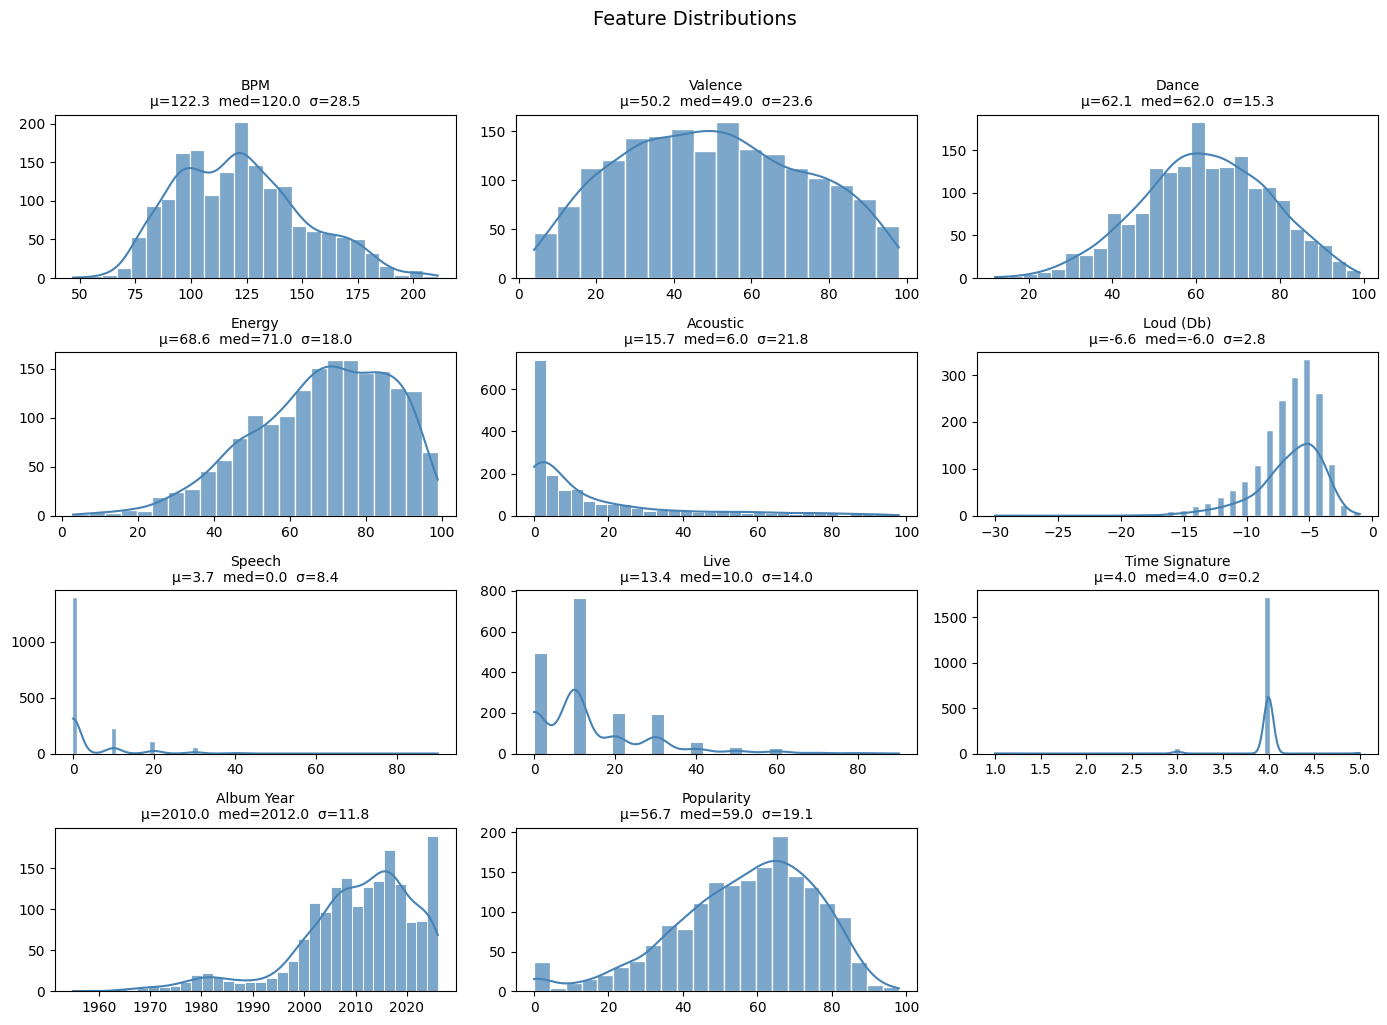

In [16]:
plot_feature_distributions(df_X)

In [17]:
# Drop 'Speech', 'Live', 'Time Signature' from features based on EDA insights
FEATURES = ['BPM', 'Valence', 'Dance', 'Energy', 'Acoustic', 'Loud (Db)', 'Album Year', 'Popularity']
df_features = df_library[FEATURES]

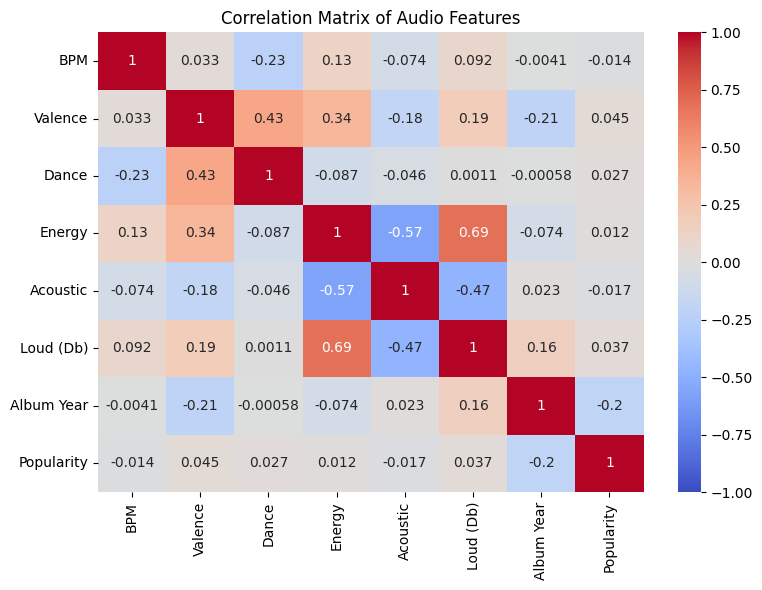

In [18]:
# Calculate and plot correlation matrix for features
df_features_corr = df_features.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(df_features_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Audio Features')
plt.tight_layout()
plt.show()

In [19]:
# Run PCA and plot variance explained to determine how many components to keep for clustering
def explore_pca(df_features):
    """Fit PCA on all components, plot variance explained, return scaler + pca."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_features)

    pca = PCA()
    pca.fit(X_scaled)
    var_explained = pca.explained_variance_ratio_
    cumulative = var_explained.cumsum()

    fig, ax = plt.subplots(figsize=(8, 5))
    x_pos = range(1, len(var_explained) + 1)
    ax.bar(x_pos, var_explained, alpha=0.7, label='Individual')
    ax.plot(x_pos, cumulative, 'ro-', label='Cumulative')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'PC{i}' for i in x_pos])
    ax.set_ylabel('Variance Explained')
    ax.set_xlabel('Principal Component')
    ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='90% threshold')
    ax.legend()
    ax.set_ylim(0, 1.05)
    plt.title('PCA Variance Explained')
    plt.tight_layout()
    plt.show()

    print("=" * 50)
    print("VARIANCE EXPLAINED")
    print("=" * 50)
    for i, (var, cum) in enumerate(zip(var_explained, cumulative)):
        print(f"PC{i+1}: {var:.1%} (cumulative: {cum:.1%})")

    return {
        'scaler': scaler,
        'pca': pca,
        'var_explained': var_explained,
        'cumulative': cumulative, 
        'X_scaled': X_scaled 
    }

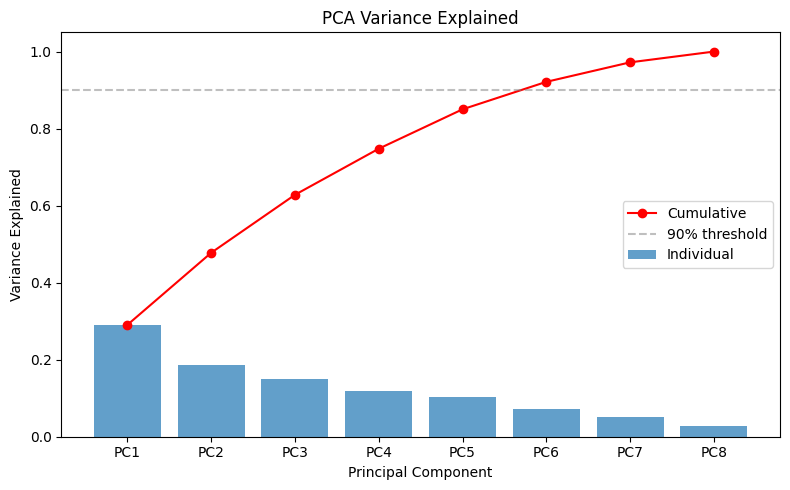

VARIANCE EXPLAINED
PC1: 29.1% (cumulative: 29.1%)
PC2: 18.7% (cumulative: 47.8%)
PC3: 15.1% (cumulative: 62.8%)
PC4: 12.0% (cumulative: 74.8%)
PC5: 10.2% (cumulative: 85.0%)
PC6: 7.1% (cumulative: 92.1%)
PC7: 5.1% (cumulative: 97.2%)
PC8: 2.8% (cumulative: 100.0%)


In [20]:
pca_results = explore_pca(df_features)